This is based on Li, Pöschl, and Shiraiwa paper 

`Molecular corridors and parameterizations of volatility in the chemical evolution of organic aerosols`

https://doi.org/10.5194/acp-16-3327-2016

Atmos.Chem.Phys.,16,3327–3344,2016

<br><br>

not entirely sure if this is what Rowshon was doing but certainly something similar. 
<br><br>

in short, they analyze a large 31K+ compounds, which can be divided into groups (such as CHON, CHOS etc)

there's a tight inverse correlation between molar mass ($M$) and volatility ($\log_{10} C^*$).

Class Specifics:

Indoor/Less-Oxidized OA: Constrained to high-volatility, low-molar-mass regions.

Aqueous/Highly Oxygenated OA: Broaden toward low volatility and higher molar mass along high O:C ratios.

Nitrogen & Sulfur Species: Amines exhibit low molar mass and high volatility, whereas organonitrates and organosulfates follow high O:C corridors extending to high molar mass and low volatility.


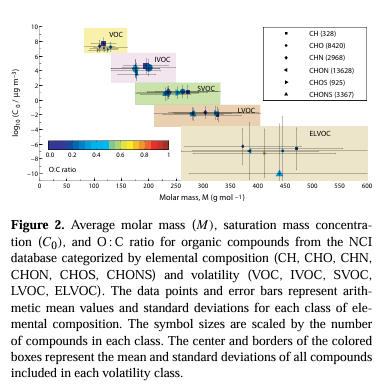

in general thhe category are classified based on 

|Category|C∗ Range (μg m−3)|Physical State / Behavior|
|:---|:---|:---|
|VOC (Volatile Organic Compounds)|$> 10^6$|Exclusively gas phase.|
IVOC (Intermediate Volatility)|$10^3$ to $10^6$|Mostly gas, but can condense if heavily concentrated.|
SVOC (Semi-Volatile)|$10^{-1}$ to $10^3$|Dynamically partitions between gas and particle phases.|
LVOC (Low Volatility)|$10^{-4}$ to $10^{-1}$|Mostly bound inside solid or liquid particles.|
ELVOC (Extremely Low Volatility)|$< 10^{-4}$|Condenses almost instantly upon formation; essentially non-volatile.|

<br><Br>

Parameterizations: The authors established revised formulas linking elemental composition ($n_{\text{C}}, n_{\text{H}}, n_{\text{O}}, n_{\text{N}}$) directly to saturation mass concentration, allowing atmospheric models to predict compound volatility without requiring full structural details.

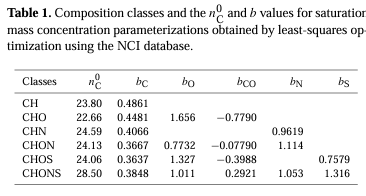

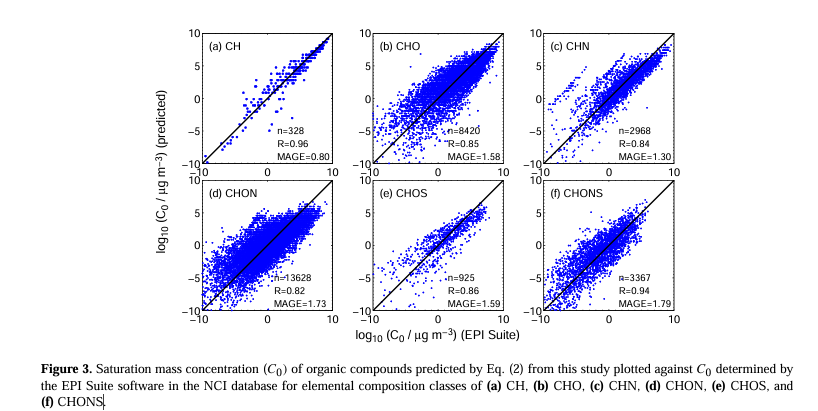

In [ ]:

COEF = {
    "CH":   dict(n0C=23.80, bC=0.4861),
    "CHO":  dict(n0C=22.66, bC=0.4481, bO=1.656,  bCO=-0.7790),
    "CHN":  dict(n0C=24.59, bC=0.4066, bN=0.9619),
    "CHON": dict(n0C=24.13, bC=0.3667, bO=0.7732, bCO=-0.0779, bN=1.114),
    "CHOS": dict(n0C=24.06, bC=0.3637, bO=1.327,  bCO=-0.3988, bS=0.7579),
    "CHONS":dict(n0C=28.50, bC=0.3848, bO=1.011,  bCO=0.2921,  bN=1.053, bS=1.316),
}

def log10_c0(nC, nO=0, nN=0, nS=0, cls=None):
    c = COEF[cls]
    val = (c["n0C"] - nC) * c["bC"]
    if nO: val -= nO * c.get("bO", 0)
    if nO and nC: val -= 2 * (nC*nO)/(nC+nO) * c.get("bCO", 0)
    if nN: val -= nN * c.get("bN", 0)
    if nS: val -= nS * c.get("bS", 0)
    return val